In [ ]:
!pip install yfinance pandas numpy matplotlib seaborn pandas-ta

In [ ]:
import yfinance as yf
ticker_symbol = "NVDA"
ticker = yf.Ticker(ticker_symbol)

In [ ]:
expirations = ticker.options
print("Available expirations:")
print(expirations)

Available expirations:
('2026-03-09', '2026-03-11', '2026-03-13', '2026-03-16', '2026-03-18', '2026-03-20', '2026-03-27', '2026-04-02', '2026-04-10', '2026-04-17', '2026-04-24', '2026-05-15', '2026-06-18', '2026-07-17', '2026-08-21', '2026-09-18', '2026-11-20', '2026-12-18', '2027-01-15', '2027-03-19', '2027-06-17', '2027-09-17', '2027-12-17', '2028-01-21', '2028-12-15')


In [ ]:
nearest_expirations = expirations[:3]
print("Selected expirations:", nearest_expirations)

Selected expirations: ('2026-03-09', '2026-03-11', '2026-03-13')


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
all_options = []

for exp in nearest_expirations:

    opt = ticker.option_chain(exp)

    calls = opt.calls.copy()
    puts = opt.puts.copy()

    calls["type"] = "call"
    puts["type"] = "put"

    calls["expiration"] = exp
    puts["expiration"] = exp

    all_options.append(calls)
    all_options.append(puts)

options_df = pd.concat(all_options, ignore_index=True)

In [ ]:
options_df = options_df[[
    "contractSymbol",
    "expiration",
    "strike",
    "type",
    "lastPrice",
    "bid",
    "ask",
    "volume",
    "openInterest",
    "impliedVolatility"
]]

In [ ]:
options_df.head()

,contractSymbol,expiration,strike,type,lastPrice,bid,ask,volume,openInterest,impliedVolatility
0,NVDA260309C00075000,2026-03-09,75.0,call,106.30,98.7,107.75,NaN,1,5.656253
1,NVDA260309C00100000,2026-03-09,100.0,call,78.17,73.7,82.80,3.0,0,3.964844
2,NVDA260309C00110000,2026-03-09,110.0,call,71.87,63.7,72.80,1.0,1,3.382814
3,NVDA260309C00115000,2026-03-09,115.0,call,62.14,58.7,67.80,3.0,3,3.107424
4,NVDA260309C00120000,2026-03-09,120.0,call,60.55,53.7,62.75,1.0,4,2.808597


In [ ]:
options_df.to_csv("nvda_option_chain.csv", index=False)

In [ ]:
calls = options_df[options_df["type"] == "call"]
puts = options_df[options_df["type"] == "put"]

put_call_ratio = puts["openInterest"].sum() / calls["openInterest"].sum()

print("Put/Call Ratio:", round(put_call_ratio,3))

Put/Call Ratio: 1.303


In [ ]:
avg_iv = options_df["impliedVolatility"].mean()

print("Average Implied Volatility:", round(avg_iv,3))

Average Implied Volatility: 1.252


In [ ]:
oi_by_strike = options_df.groupby("strike")["openInterest"].sum()

In [ ]:
oi_by_exp = options_df.groupby("expiration")["openInterest"].sum()

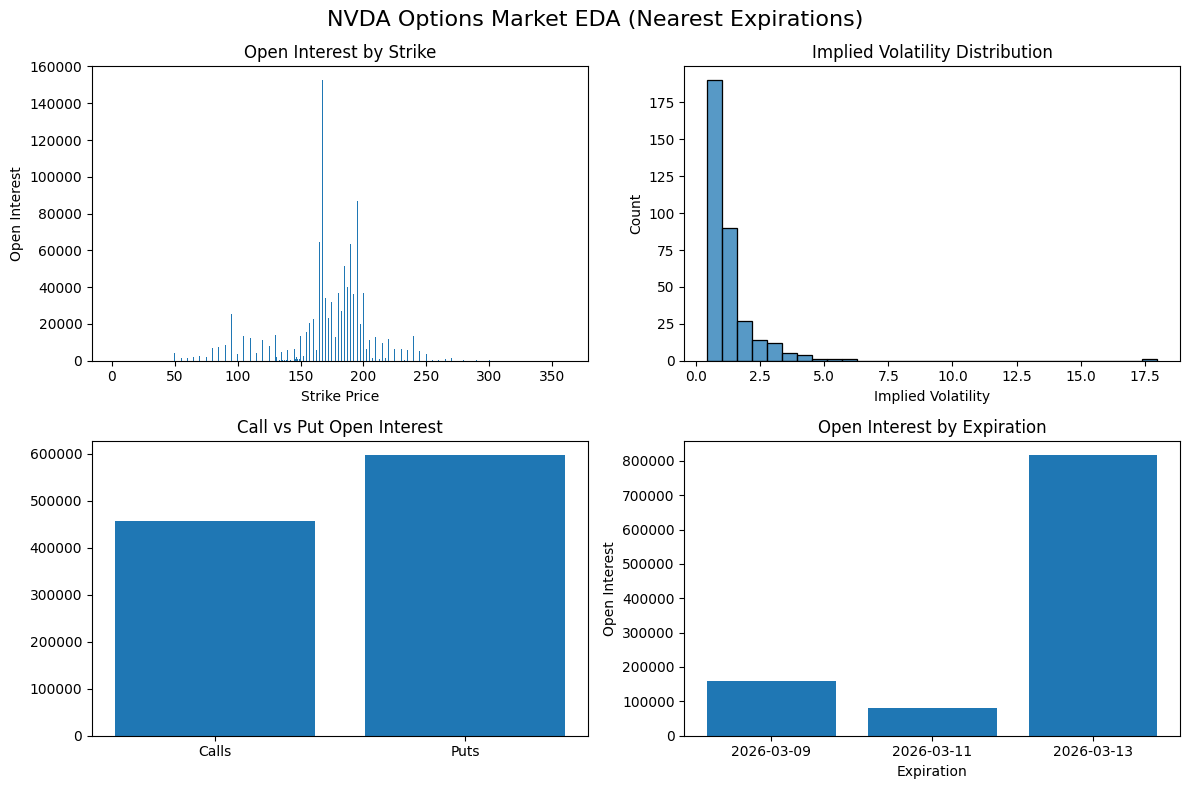

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(12,8))

fig.suptitle("NVDA Options Market EDA (Nearest Expirations)", fontsize=16)

# 1 Open Interest by Strike
axes[0,0].bar(oi_by_strike.index, oi_by_strike.values)
axes[0,0].set_title("Open Interest by Strike")
axes[0,0].set_xlabel("Strike Price")
axes[0,0].set_ylabel("Open Interest")

# 2 Implied Volatility Distribution
sns.histplot(options_df["impliedVolatility"], bins=30, ax=axes[0,1])
axes[0,1].set_title("Implied Volatility Distribution")
axes[0,1].set_xlabel("Implied Volatility")

# 3 Call vs Put Open Interest
call_oi = calls["openInterest"].sum()
put_oi = puts["openInterest"].sum()

axes[1,0].bar(["Calls","Puts"], [call_oi, put_oi])
axes[1,0].set_title("Call vs Put Open Interest")

# 4 Open Interest by Expiration
axes[1,1].bar(oi_by_exp.index.astype(str), oi_by_exp.values)
axes[1,1].set_title("Open Interest by Expiration")
axes[1,1].set_xlabel("Expiration")
axes[1,1].set_ylabel("Open Interest")

plt.tight_layout()
plt.show()

In [ ]:
from datetime import datetime, timedelta

ticker = yf.Ticker("TSLA")

news = ticker.news

In [ ]:
rows = []

for article in news:
    content = article["content"]

    rows.append({
        "title": content.get("title"),
        "summary": content.get("summary"),
        "publisher": content.get("provider", {}).get("displayName"),
        "date": content.get("pubDate"),
        "url": content.get("canonicalUrl", {}).get("url")
    })

news_df = pd.DataFrame(rows)

In [ ]:
news_df["date"] = pd.to_datetime(news_df["date"])

news_df

,title,summary,publisher,date,url
0,Nvidia and Meta Platforms Are Now Cheaper Than...,Investors are getting a great price for these ...,Motley Fool,2026-03-08 19:37:00+00:00,https://www.fool.com/investing/2026/03/08/nvid...
1,Tesla's Europe Registrations Rise 10% In Febru...,Tesla Inc. has recorded an uptick in its repor...,Benzinga,2026-03-08 19:30:22+00:00,https://finance.yahoo.com/news/teslas-europe-r...
2,Elon Musk Announced In 2020 To Own Almost Noth...,Elon Musk in 2020 posted a message that sounde...,Benzinga,2026-03-08 18:00:33+00:00,https://finance.yahoo.com/news/elon-musk-annou...
3,Bank of America resets Amazon stock forecast,"Amazon stock has lost about 7% year to date, a...",TheStreet,2026-03-08 16:47:00+00:00,https://www.thestreet.com/investing/stocks/ban...
4,"Maye Musk Shares Emotional Tesla Crash Story, ...","On Thursday, Maye Musk shared an emotional sto...",Benzinga,2026-03-08 14:30:32+00:00,https://finance.yahoo.com/news/maye-musk-share...
5,YieldMax’s TSLA Option Income ETF Has a 60%+ Y...,TSLY paid out more than $10.78 in distribution...,24/7 Wall St.,2026-03-08 12:07:52+00:00,https://247wallst.com/investing/2026/03/08/yie...
6,What to Expect in Markets This Week: Data on I...,Coming up: February CPI and January PCE inflat...,Investopedia,2026-03-08 10:15:00+00:00,https://www.investopedia.com/what-to-expect-in...
7,Tesla Optimus Robot Push Reshapes Growth Story...,Tesla is shifting a portion of its Fremont fac...,Simply Wall St.,2026-03-08 00:17:18+00:00,https://finance.yahoo.com/news/tesla-optimus-r...
8,"The Best ""Magnificent Seven"" Stocks to Buy in ...",The market is gifting investors several potent...,Motley Fool,2026-03-07 23:26:00+00:00,https://www.fool.com/investing/2026/03/07/the-...
9,Tesla Robotaxi Rival Waymo Now Operates In 10 ...,Alphabet Inc.-backed Waymo announced that it i...,Benzinga,2026-03-07 21:30:44+00:00,https://finance.yahoo.com/news/tesla-robotaxi-...


In [ ]:
len(news_df)

10

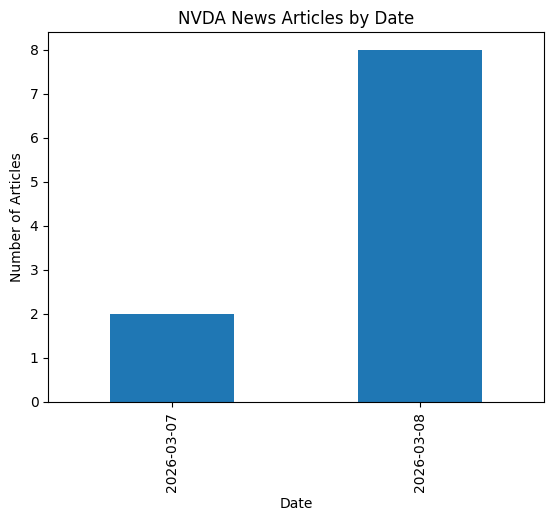

In [ ]:
import matplotlib.pyplot as plt

news_df["date"].dt.date.value_counts().sort_index().plot(kind="bar")

plt.title("NVDA News Articles by Date")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.show()